# Bright High-z Targets


No targets fall within a 3.6' NIRSpec MSA radius.


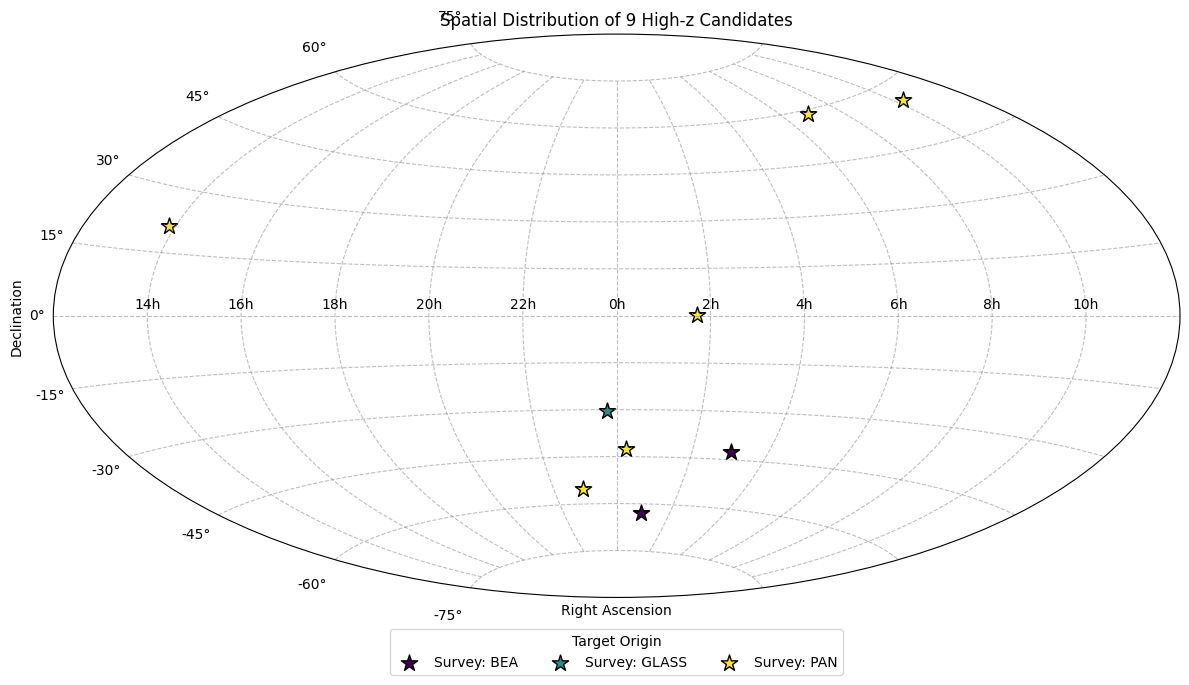

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import collections

# --- 1. Coordinate and Survey Data (Replace with your ~20 targets) ---

# Example target data (IDs, full strings, and originating survey)
targets_data = [
    ("PAN-0104-5508-2026296", "01:04:17.50 -55:07:35.55", "PAN"),
    ("PAN-1007+2109-2040861", "10:07:44.02 +21:11:00.98", "PAN"),
    ("PAN-1343+5549-2000350", "13:43:39.91 +55:46:45.76", "PAN"),
    ("PAN-1707+5852-2010068", "17:07:17.36 +58:51:11.06", "PAN"),
    ("BEA-2303-6250-2039802", "23:03:34.42 -62:50:11.26", "BEA"),
    ("GLASS-2039052", "00:13:59.75 -30:19:29.14", "GLASS"),
    ("BEA-2303-6250-2039802", "20:58:33.74 -42:44:08.61", "BEA"),
    ("PAN-2216+0024-3003658", "22:17:00.12 +00:22:44.69", "PAN"), 
    ("PAN-2345-4235-3022235", "23:45:15.45 -42:34:57.07", "PAN"), 
]

# Extract coordinates and surveys
coord_strings = [t[1] for t in targets_data]
survey_list = [t[2] for t in targets_data]

# Parse with Astropy
coords = SkyCoord(coord_strings, unit=(u.hourangle, u.deg), frame='icrs')

# Check for multipletarget pointings (MSA radius ~3.6 arcmin)
max_sep = 3.6 * u.arcmin
from astropy.coordinates import search_around_sky
idx1, idx2, sep2d, _ = search_around_sky(coords, coords, seplimit=max_sep)
unique_pairs = idx1 < idx2
matching_pairs = list(zip(idx1[unique_pairs], idx2[unique_pairs], sep2d[unique_pairs]))

# Identify pointings with multiples (using indices of targets with neighbors)
multiple_target_indices = set(idx1[unique_pairs]) | set(idx2[unique_pairs])

# --- 2. Map Categorization & Color Setup ---

# Get unique surveys and map colors
unique_surveys = sorted(list(set(survey_list)))
color_map_name = 'viridis' # 'Set1', 'Dark2', 'plasma' also good for categorization
cmap = plt.get_cmap(color_map_name, len(unique_surveys))
survey_colors = {survey: cmap(i) for i, survey in enumerate(unique_surveys)}

# Handle coordinate wrapping and radian conversion for Aitoff
# Center the map at RA=0 (wrapping at 180 deg)
ra_wrapped = coords.ra.wrap_at(180 * u.deg)
ra_rad = ra_wrapped.radian
dec_rad = coords.dec.radian

# --- 3. Plot Initialization (Aitoff) ---
fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(111, projection='aitoff')
ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# Flip the X-axis manually (Astronomy convention, RA increasing Left)
# ax.set_xlim(np.pi, -np.pi)

# Set grid labels (formatting in standard RA/Dec hours/degrees)
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'])
# ax.set_yticklabels(['-75°', '-60°', '-45°', '-30°', '-15°', '0°', '15°', '30°', '45°', '60°', '75°']) # Can adjust y-ticks

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
plt.title(f"Spatial Distribution of {len(targets_data)} High-z Candidates")

# --- 4. Plot Targets with Color Coding ---
marker_size = 150

# Track plotted surveys for the legend
plotted_surveys = set()

for i, (ra, dec, survey) in enumerate(zip(ra_rad, dec_rad, survey_list)):
    
    # Define visual properties
    color = survey_colors[survey]
    edge_color = 'black'
    alpha = 1.0
    
    # Highlight potential multiplets with a slightly different style
    if i in multiple_target_indices:
        marker = 'D' # Diamond for multiples
        linewidth = 2.0
    else:
        marker = '*' # Star for singles
        linewidth = 1.0

    # Plot, adding to legend only once per survey
    if survey not in plotted_surveys:
        ax.scatter(-ra, dec, color=color, marker=marker, s=marker_size, 
                   edgecolors=edge_color, linewidths=linewidth, alpha=alpha, label=f"Survey: {survey}")
        plotted_surveys.add(survey)
    else:
        ax.scatter(-ra, dec, color=color, marker=marker, s=marker_size, 
                   edgecolors=edge_color, linewidths=linewidth, alpha=alpha)

# --- 5. Format Legend and Display Info ---
# Collect legend handles and labels, ensuring they are in order of plotted surveys
handles, labels = ax.get_legend_handles_labels()
# Sorting the legend by survey name
by_label = collections.OrderedDict(sorted(zip(labels, handles), key=lambda t: t[0]))
plt.legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=len(unique_surveys), title="Target Origin", frameon=True)

# Annotate multiplexing information
if matching_pairs:
    print(f"\nPotential Multi-Target NIRSpec Pointings Found:")
    for m in matching_pairs:
        t1 = targets_data[m[0]][0]
        t2 = targets_data[m[1]][0]
        print(f"  Targets {t1} and {t2} separated by {m[2].to(u.arcmin):.2f}")
else:
    print("\nNo targets fall within a 3.6' NIRSpec MSA radius.")

plt.tight_layout()
plt.show()

In [2]:
import astropy.units as u
from astropy.coordinates import search_around_sky

# Define your search radius (e.g., 3 arcminutes for NIRSpec MSA footprint)
max_sep = 3.0 * u.arcmin

# Compare the target list against itself
idx1, idx2, sep2d, dist3d = search_around_sky(coords, coords, seplimit=max_sep)

# Filter out self-matches (where a target matches with itself at 0 distance)
unique_pairs = idx1 < idx2
idx1 = idx1[unique_pairs]
idx2 = idx2[unique_pairs]
sep2d = sep2d[unique_pairs]

# Print the results
if len(idx1) > 0:
    print(f"Found {len(idx1)} potential multi-target pointings:")
    for i, j, sep in zip(idx1, idx2, sep2d):
        print(f"  Target {i} and Target {j} are separated by {sep.to(u.arcmin):.2f}")
else:
    print("No multiple targets found within the specified pointing radius.")

No multiple targets found within the specified pointing radius.


# LRD Selection

- MCMC fit to Ly-alpha + continuum restframe UV
- AB magnitude > 27 in F115W or F150W (depending on redshift)

In [16]:
import glob
from astropy.table import Table
from astropy.io import fits
import numpy as np

def find_all(output_dir):
    zout_files = sorted(glob.glob(f"{output_dir}*.ecsv"))

    if not zout_files:
        raise FileNotFoundError(f"No .ecsv files found in {output_dir}")

    all_highz_sources = []

    print(f"Scanning {len(zout_files)} output segments...")
    for ffile in zout_files:
        # Read EAZY output table
        zout = Table.read(ffile, format='ascii')
        
        # Filter for high-z candidates (using standard EAZY peak or median redshift)
        if len(zout) > 0:
            all_highz_sources.append(zout)

    # Combine all extracted rows into a single table
    if all_highz_sources:
        # master_table = collections.get_identity if len(all_highz_sources) == 1 else None
        # If more than one table, stack them
        from astropy.table import vstack
        master_table = vstack(all_highz_sources)

        return master_table

    else:
        print('Could not find any data.')
        return None
    
def perform_selection(data, z_col, f115w_col, f150w_col, mag_limit=27, flux_limit=0.0575, is_abmag=True):
    """
    Perform selection of high-z candidates based on redshift and AB magnitude.

    Parameters:
    - data: Astropy Table containing the photometric data.
    - z_col: Column name for redshift.
    - f115w_col: Column name for F115W magnitude.
    - f150w_col: Column name for F150W magnitude.
    - mag_limit: Magnitude limit for selection (default is 27).
    - flux_limit: Flux limit for selection in microjanskys (default is 0.0575).
    - is_abmag: Boolean indicating if magnitudes are in AB system (default is True).

    Returns:
    - selected_115: Subset of data with z in [6.9, 7.06) and F115W < mag_limit.
    - selected_150: Subset of data with z >= 7.06 and F150W < mag_limit.
    """
    if is_abmag: # Do filtration directly using AB magnitudes
        selected_115 = data[(data[z_col] > 6.9) & (data[z_col] < 7.06) & (data[f115w_col] < mag_limit) & (data[f115w_col] > -99)]
        selected_150 = data[(data[z_col] >= 7.06) & (data[f150w_col] < mag_limit) & (data[f150w_col] > -99)]
        
        return selected_115, selected_150
    
    else: # Filter based on ABmag flux equivalent in microjanskys
        selected_115 = data[(data[z_col] > 6.9) & (data[z_col] < 7.06) & (data[f115w_col] > flux_limit)]
        selected_150 = data[(data[z_col] >= 7.06) & (data[f150w_col] > flux_limit)]

        return selected_115, selected_150

In [72]:
# 2 sources from Xiao: GOODS-N IDs 1087167, 1085466 - no spectra in FitsMap
# COSMOS-WEB LRDs at https://github.com/hollisakins/akins24_cw

akins_phot = Table.read('../../akins24_cw/COSMOS-Web_LRDs.dat', format='ascii.ecsv')
kokorev_phot = Table.read('../lrd_data/VasilyKokorev-lrd_phot-a69c4c7/lrd_table_v1.1.fits')
master_table_n = find_all('../inputs/OUTPUT_N/')
PRISM_RES = Table.read('../jwst_nirspec_prism_disp.fits')

xiao_ids = [1087167, 1085466]
xiao_phot = master_table_n[np.isin(master_table_n['id'], xiao_ids)]

Scanning 13 output segments...


In [73]:
# Filter by redshift z > 6.9, then by AB magnitude in F115W or F150W as appropriate
# F115W moves into Gunn-Peterson trough at z > 7 so just use F150W

akins_115, akins_150 = perform_selection(akins_phot, 'z_gal_med', 'm115', 'm150', mag_limit=27, is_abmag=True)
kokorev_115, kokorev_150 = perform_selection(kokorev_phot, 'z_phot', 'f115w_flux', 'f150w_flux', flux_limit=0.0575, is_abmag=False)
xiao_115, xiao_150 = perform_selection(xiao_phot, 'z_a', 'f_nircam_f115w', 'f_nircam_f150w', flux_limit=0.0575, is_abmag=False)

print(f"AKINS: {len(akins_115)} candidates in 6.9 < z < 7.06, {len(akins_150)} candidates at z >= 7.06")
print(f"KOKOREV: {len(kokorev_115)} candidates in 6.9 < z < 7.06, {len(kokorev_150)} candidates at z >= 7.06")
print(f"XIAO: {len(xiao_115)} candidates in 6.9 < z < 7.06, {len (xiao_150)} candidates at z >= 7.06")

AKINS: 1 candidates in 6.9 < z < 7.06, 9 candidates at z >= 7.06
KOKOREV: 1 candidates in 6.9 < z < 7.06, 4 candidates at z >= 7.06
XIAO: 0 candidates in 6.9 < z < 7.06, 2 candidates at z >= 7.06


In [74]:
li_spectra = Table.read('../lrd_data/deGraaff2025_lrds_withdups_blackbody_eline_fits.fits')
print(len(li_spectra), "sources in de Graaff (2025) LRD catalog")

li_spectra_highz = li_spectra[li_spectra['zspec'] > 6.9]
print(len(li_spectra_highz), "high-redshift sources (z > 6.9)")

134 sources in de Graaff (2025) LRD catalog
21 high-redshift sources (z > 6.9)


In [ ]:
def calculate_rest_uv_mag(obs_wave, obs_flux, z_spec, lambda_pivot_rest=1500.0, width_rest=200.0):
    """
    Calculates rest-frame UV AB magnitude from an observed spectrum.
    obs_wave: array of observed wavelengths in microns
    obs_flux: array of observed flux densities in microJanskies (uJy)
    """
    # 1. Define the top-hat filter limits in rest-frame Angstroms
    w_min_rest = lambda_pivot_rest - (width_rest / 2.0)
    w_max_rest = lambda_pivot_rest + (width_rest / 2.0)
    
    # 2. Redshift the filter edges to observed microns
    w_min_obs = (w_min_rest * (1.0 + z_spec)) / 10000.0
    w_max_obs = (w_max_rest * (1.0 + z_spec)) / 10000.0
    
    # 3. Create the filter response curve on your spectrum's wavelength grid
    # 1.0 inside the band window, 0.0 outside
    R = np.where((obs_wave >= w_min_obs) & (obs_wave <= w_max_obs), 1.0, 0.0)
    
    # Check if the filter actually overlaps with your data footprint
    if np.sum(R) == 0:
        raise ValueError("The redshifted UV window falls outside the observed spectral coverage!")
        
    # 4. Perform photon-weighted integration (Equation above)
    integrand_top = obs_flux * R * obs_wave
    integrand_bottom = R * obs_wave
    
    f_nu_bar_ujy = np.trapz(integrand_top, obs_wave) / np.trapz(integrand_bottom, obs_wave)
    
    # 5. Convert microJanskies to AB Magnitude
    m_ab = 23.9 - 2.5 * np.log10(f_nu_bar_ujy)
    
    return m_ab, f_nu_bar_ujy

Source at z=9.294 has rest-frame UV AB mag = 28.82 (f_nu_bar = 0.0108 uJy)
Building instrumental LSF matrix...
Running MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [00:09<00:00, 161.73it/s]



--- Fit Results ---
A = 0.012 (+0.001, -0.001)
$\beta$ = 1.849 (+0.108, -0.179)
$F_{\rm Ly\alpha}$ = 0.000 (+0.000, -0.000)
$\sigma_{\rm Ly\alpha}$ = 38.732 (+43.090, -29.507)
LyA Detection S/N = 0.90
Source at z=8.357 has rest-frame UV AB mag = 27.38 (f_nu_bar = 0.0405 uJy)
Building instrumental LSF matrix...
Running MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [00:08<00:00, 177.44it/s]



--- Fit Results ---
A = 0.041 (+0.001, -0.001)
$\beta$ = 0.870 (+0.069, -0.071)
$F_{\rm Ly\alpha}$ = 0.000 (+0.000, -0.000)
$\sigma_{\rm Ly\alpha}$ = 53.735 (+32.727, -37.056)
LyA Detection S/N = 0.68
Source at z=7.153 has rest-frame UV AB mag = 28.87 (f_nu_bar = 0.0102 uJy)
Building instrumental LSF matrix...
Running MCMC chain with 32 walkers for 1500 steps...


...


--- Fit Results ---
A = 0.001 (+0.001, -0.001)
$\beta$ = -0.001 (+1.394, -2.178)
$F_{\rm Ly\alpha}$ = 0.002 (+0.001, -0.001)
$\sigma_{\rm Ly\alpha}$ = 68.134 (+21.685, -29.315)
LyA Detection S/N = 1.50
Source at z=7.764 has rest-frame UV AB mag = 29.47 (f_nu_bar = 0.0059 uJy)
Building instrumental LSF matrix...
Running MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [00:07<00:00, 189.06it/s]



--- Fit Results ---
A = 0.010 (+0.001, -0.001)
$\beta$ = 1.679 (+0.218, -0.371)
$F_{\rm Ly\alpha}$ = 0.000 (+0.000, -0.000)
$\sigma_{\rm Ly\alpha}$ = 36.570 (+42.976, -25.168)
LyA Detection S/N = 1.07
Source at z=7.098 has rest-frame UV AB mag = 27.91 (f_nu_bar = 0.0250 uJy)
Building instrumental LSF matrix...
Running MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [00:23<00:00, 63.67it/s] 



--- Fit Results ---
A = 0.034 (+0.001, -0.001)
$\beta$ = 1.010 (+0.126, -0.118)
$F_{\rm Ly\alpha}$ = 0.001 (+0.000, -0.000)
$\sigma_{\rm Ly\alpha}$ = 3.211 (+3.515, -1.641)
LyA Detection S/N = 4.20
LyA line detected with S/N > 3.0 for source mom-uds02-v4_prism-clear_5224_920396.spec.fits at z=7.098


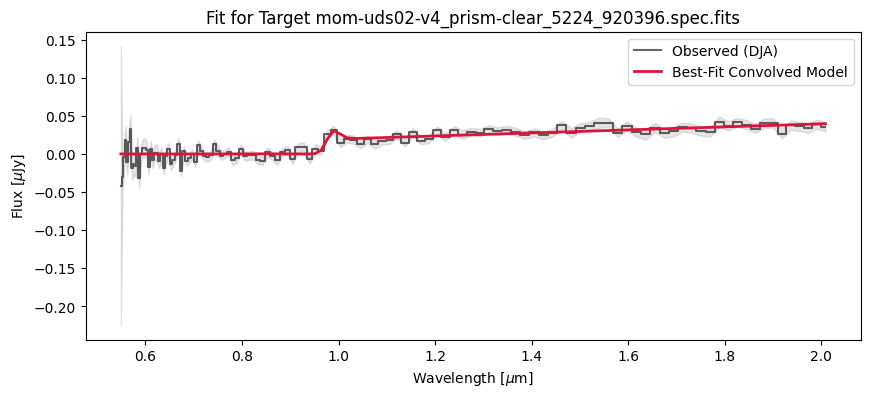

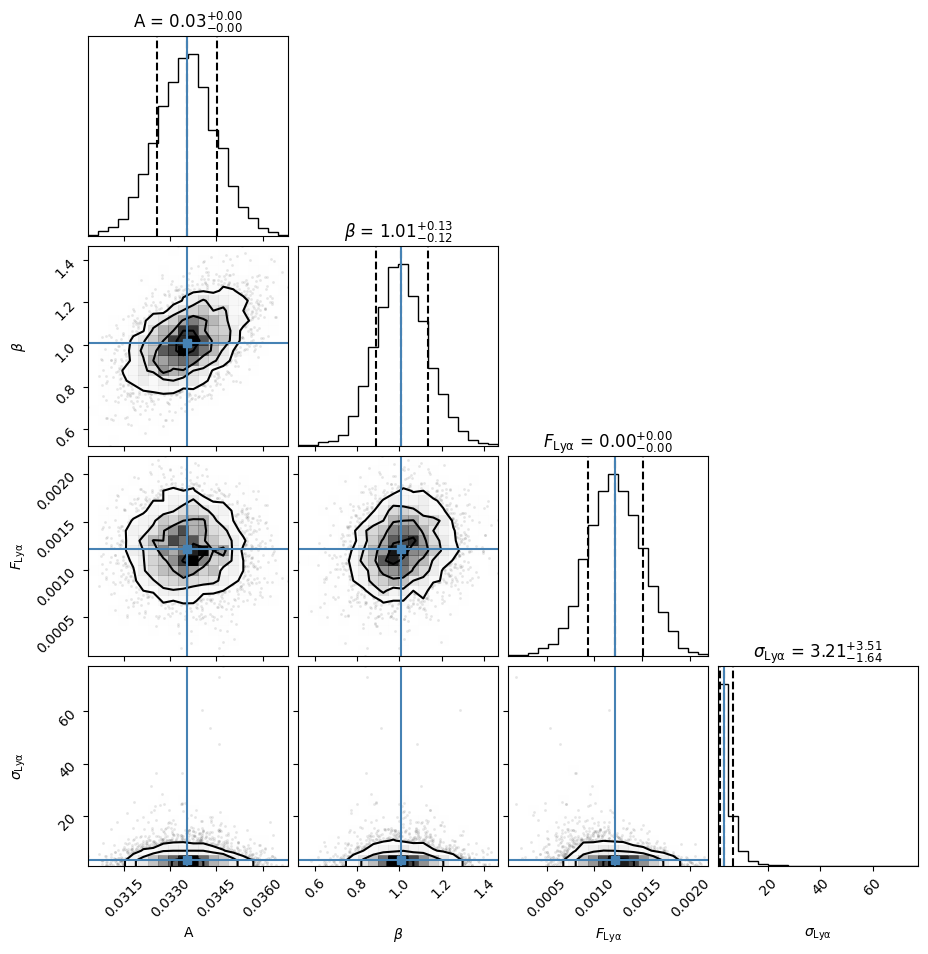

In [234]:
# 1. Define your path tokens
for source in li_spectra_highz:
    dja_root = source['root']
    filename = source['file']

    # 2. Construct the direct Amazon S3 URL
    dja_base_url = "https://s3.amazonaws.com/msaexp-nirspec/extractions/"
    full_url = f"{dja_base_url}{dja_root}/{filename}"

    # print(f"Loading from: {full_url}")

    # 3. Open directly from the web using astropy.io.fits
    with fits.open(full_url) as hdul:
        # hdul.info()  # This will show you the file structure (SCI, WHT, SPEC1D)
        
        # Extract the 1D spectrum table data (usually extension 1: 'SPEC1D')
        spec_data = Table(hdul['SPEC1D'].data)
        
        # Extract 2D spectrum arrays if you need them for validation
        sci_2d = hdul['SCI'].data
        wht_2d = hdul['WHT'].data

    # 4. View the table columns available for fitting
    # print("\nAvailable columns:", spec_data.colnames)
    # DJA spec.fits files typically include: 'wave', 'flux', 'err', 'cont'

    mask = np.isfinite(spec_data['flux']) & (spec_data['err'] > 0)
    obs_wave = np.array(spec_data['wave'][mask])  # microns
    obs_flux = np.array(spec_data['flux'][mask])  # microJanskies
    obs_err  = np.array(spec_data['err'][mask])   # microJanskies

    m_ab, f_nu_bar_ujy = calculate_rest_uv_mag(obs_wave, obs_flux, source['zspec'])

    # if m_ab < 27:
    print(f"Source at z={source['zspec']:.3f} has rest-frame UV AB mag = {m_ab:.2f} (f_nu_bar = {f_nu_bar_ujy:.4f} uJy)")

    z_source = source['zspec'] # Grab this from the de Graaff (2025) catalog entry for this source
    lambda_0 = 17000.0#  # Reference wavelength in Angstroms (per Calzetti/paper convention)

    wave_cutoff = 2500 * (z_source + 1) / 10000.0  # To select close to Lyman limit
    # Filter out bad pixels and edge artifacts
    mask = np.isfinite(spec_data['flux']) & (spec_data['err'] > 0) & (spec_data['wave'] < wave_cutoff)
    obs_wave = np.array(spec_data['wave'][mask])  # microns
    obs_flux = np.array(spec_data['flux'][mask])  # microJanskies
    obs_err  = np.array(spec_data['err'][mask])   # microJanskies

    # ==========================================
    # 2. PRE-COMPUTE THE VARIABLE LSF MATRIX
    # ==========================================
    # Generate a fine, high-res wavelength grid for the forward model 
    # to accurately resolve line profiles before instrumental blurring
    model_wave = np.linspace(obs_wave.min() - 0.05, obs_wave.max() + 0.05, 1500)

    def get_prism_resolution(wave_um):
        """
        Returns the resolving power R of the JWST NIRSpec PRISM as a function 
        of wavelength in microns. Handles both individual floats and NumPy arrays.
        """
        # np.interp(x_target, x_data, y_data)
        return np.interp(wave_um, PRISM_RES['WAVELENGTH'], PRISM_RES['R'])

    def build_lsf_matrix(model_w, obs_w):
        """Builds a variable-width matrix to convolve and downsample simultaneously."""
        matrix = np.zeros((len(obs_w), len(model_w)))
        R = get_prism_resolution(obs_w)
        
        for i, w_obs in enumerate(obs_w):
            # Instrumental sigma in microns
            sigma = w_obs / (R[i] * 2.355)
            # Evaluate Gaussian profile on the fine model grid
            gaussian = np.exp(-0.5 * ((model_w - w_obs) / sigma)**2)
            # Normalize row
            matrix[i, :] = gaussian / np.sum(gaussian)
        return matrix

    print("Building instrumental LSF matrix...")
    lsf_matrix = build_lsf_matrix(model_wave, obs_wave)

    # Initialize IGM Model (Inoue 2014)
    igm = eazy.igm.Inoue14()
    # Compute IGM transmission on our fine model grid (converted to Angstroms)
    t_igm = igm.full_IGM(z_source, model_wave * 10000.0)

    # ==========================================
    # 3. DEFINE BAYESIAN MODEL FUNCTIONS
    # ==========================================
    def log_prior(theta):
        A, beta, F_Lya, sigma_Lya = theta
        # Broad, physically motivated uniform priors
        if 0.0 < A < 100.0 and -4.0 < beta < 2.0 and 0.0 <= F_Lya < 50.0 and 1.0 < sigma_Lya < 100.0:
            return 0.0
        return -np.inf

    def forward_model(theta):
        A, beta, F_Lya, sigma_Lya = theta
        
        # Rest-frame and observed Lya wavelength setups
        lambda_Lya_rest = 1215.67  # Angstroms
        lambda_Lya_obs = lambda_Lya_rest * (1.0 + z_source) / 10000.0  # microns
        
        # Continuum component (Eq 1): Power law
        # Coverting model_wave to Angstroms for the continuum calculation
        wave_A = model_wave * 10000.0
        flux_cont = A * (wave_A / lambda_0)**beta
        
        # LyA Line component (Eq 1): Gaussian profile in wavelength space
        # sigma_Lya from MCMC is given in Angstroms, convert profile to microns
        sigma_Lya_um = sigma_Lya * (1.0 + z_source) / 10000.0
        flux_line = (F_Lya / (np.sqrt(2 * np.pi) * sigma_Lya_um)) * np.exp(-0.5 * ((model_wave - lambda_Lya_obs) / sigma_Lya_um)**2)
        
        # Intrinsic spectrum
        f_int = flux_cont + flux_line
        
        # Equation 2: Apply IGM transmission
        f_trans = f_int * t_igm
        
        # Equation 3: Convolve with LSF and downsample to observed pixels
        f_model_obs = np.dot(lsf_matrix, f_trans)
        return f_model_obs

    def log_likelihood(theta):
        f_model = forward_model(theta)
        # Equation 4: Gaussian Likelihood
        chi2 = np.sum(((obs_flux - f_model) / obs_err)**2)
        return -0.5 * chi2

    def log_probability(theta):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(theta)

    # ==========================================
    # 4. RUN EMCEE SAMPLER
    # ==========================================
    ndim = 4
    nwalkers = 32
    nsteps = 1500

    # Guess starting values: [A, beta, F_Lya, sigma_Lya]
    initial_guess = [1.5, -1.5, 5.0, 15.0]
    pos = initial_guess + 1e-3 * np.random.randn(nwalkers, ndim)

    print(f"Running MCMC chain with {nwalkers} walkers for {nsteps} steps...")
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

    # Run MCMC
    sampler.run_mcmc(pos, nsteps, progress=True)

    # ==========================================
    # 5. POST-PROCESSING & PLOTTING
    # ==========================================
    # Discard the first 300 steps as burn-in
    flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)

    # Extract best-fit parameters (median values)
    best_fit_theta = np.median(flat_samples, axis=0)
    labels = ["A", r"$\beta$", r"$F_{\rm Ly\alpha}$", r"$\sigma_{\rm Ly\alpha}$"]

    print("\n--- Fit Results ---")
    for i in range(ndim):
        p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
        print(f"{labels[i]} = {p50:.3f} (+{p84-p50:.3f}, -{p50-p16:.3f})")

    # Calculate Signal-to-Noise ratio threshold defined in paper
    f_lya_mcmc = flat_samples[:, 2]
    snr = np.median(f_lya_mcmc) / np.std(f_lya_mcmc)
    print(f"LyA Detection S/N = {snr:.2f}")

    if snr > 3.0:
        print(f"LyA line detected with S/N > 3.0 for source {filename} at z={z_source:.3f}")
        # --- Plot 1: The Spectrum and Model Fit ---
        plt.figure(figsize=(10, 4))
        plt.step(obs_wave, obs_flux, where='mid', color='black', alpha=0.6, label='Observed (DJA)')
        plt.fill_between(obs_wave, obs_flux - obs_err, obs_flux + obs_err, color='gray', alpha=0.2)
        plt.plot(obs_wave, forward_model(best_fit_theta), color='crimson', lw=2, label='Best-Fit Convolved Model')
        plt.xlabel(r'Wavelength [$\mu$m]')
        plt.ylabel(r'Flux [$ \mu $Jy]')
        plt.title(f"Fit for Target {filename}")
        plt.legend()
        plt.show()  # Render the first plot cleanly

        # --- Plot 2: The Posterior Corner Plot ---
        # Let corner handle the creation of the 4x4 matrix figure automatically
        fig = corner.corner(
            flat_samples, 
            labels=labels, 
            truths=best_fit_theta,
            quantiles=[0.16, 0.50, 0.84],
            show_titles=True,
            title_kwargs={"fontsize": 12}
        )
        plt.show()

        break

Fetching spectrum from DJA...
Building instrumental LSF matrix...
Running MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [00:04<00:00, 346.53it/s]



--- Fit Results ---
A = 0.034 (+0.001, -0.001)
$\beta$ = 0.745 (+0.122, -0.113)
$F_{\rm Ly\alpha}$ = 0.001 (+0.000, -0.000)
$\sigma_{\rm Ly\alpha}$ = 8.449 (+66.722, -6.369)
LyA Detection S/N = 1.74


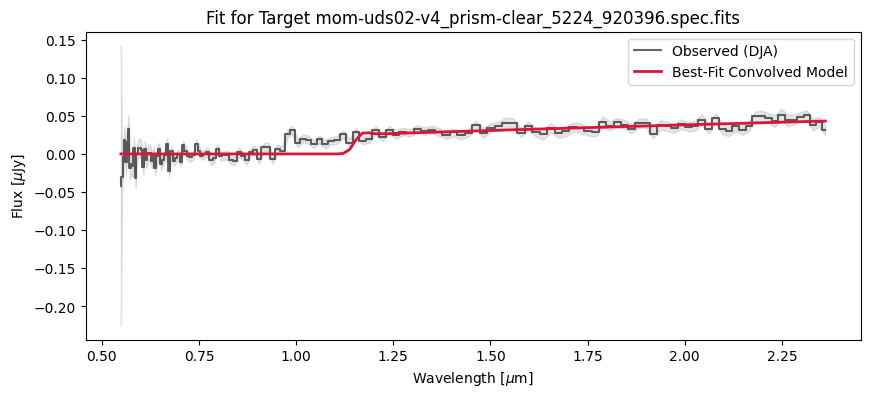

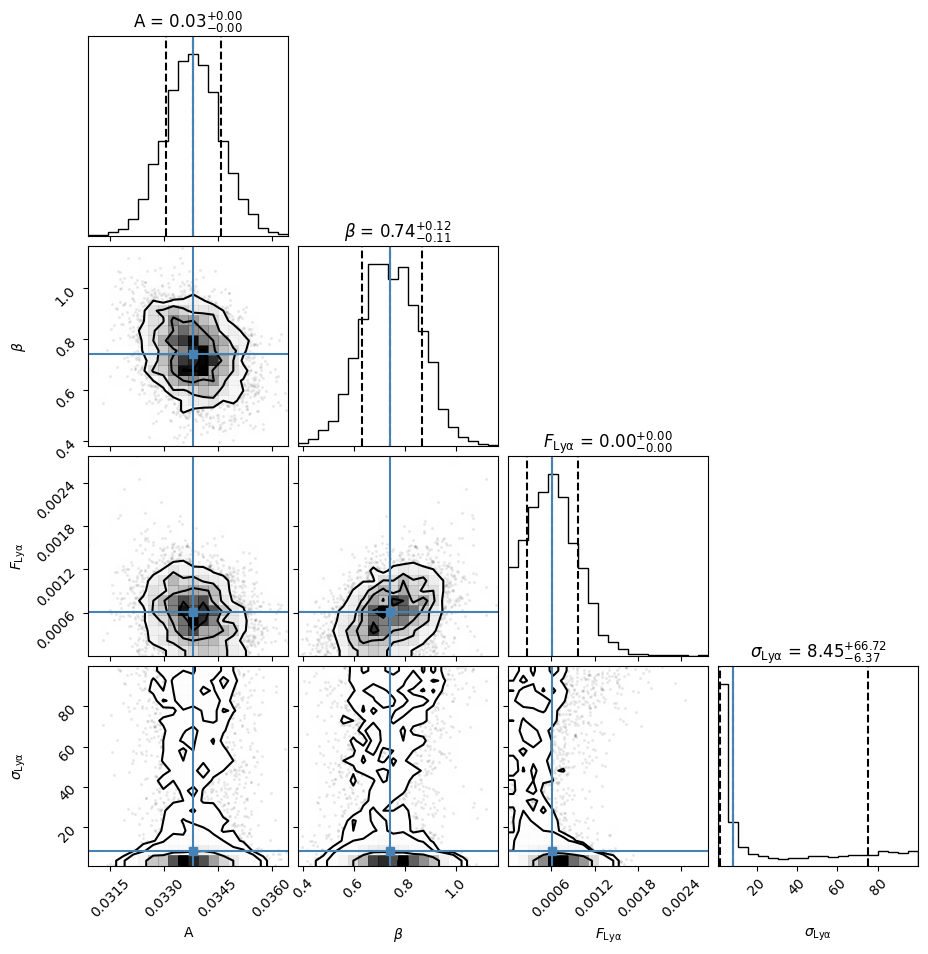

In [231]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import emcee
import corner
import eazy.igm

# ==========================================
# 1. LOAD OBSERVATIONAL DATA FROM DJA
# ==========================================
# (Using the file path structure you fetched earlier)
dja_root = "mom-uds02-v4"
filename = "mom-uds02-v4_prism-clear_5224_920396.spec.fits"
full_url = f"https://s3.amazonaws.com/msaexp-nirspec/extractions/{dja_root}/{filename}"

print("Fetching spectrum from DJA...")
with fits.open(full_url) as hdul:
    spec_data = Table(hdul['SPEC1D'].data)

# Assume a spectroscopic redshift for setting bounds and IGM
z_source = 8.509481 # Grab this from the de Graaff (2025) catalog entry for this source
lambda_0 = 17000.0#  # Reference wavelength in Angstroms (per Calzetti/paper convention)

wave_cutoff = 2500 * (z_source + 1) / 10000.0  # To select close to Lyman limit
# Filter out bad pixels and edge artifacts
mask = np.isfinite(spec_data['flux']) & (spec_data['err'] > 0) & (spec_data['wave'] < wave_cutoff)
obs_wave = np.array(spec_data['wave'][mask])  # microns
obs_flux = np.array(spec_data['flux'][mask])  # microJanskies
obs_err  = np.array(spec_data['err'][mask])   # microJanskies

# ==========================================
# 2. PRE-COMPUTE THE VARIABLE LSF MATRIX
# ==========================================
# Generate a fine, high-res wavelength grid for the forward model 
# to accurately resolve line profiles before instrumental blurring
model_wave = np.linspace(obs_wave.min() - 0.05, obs_wave.max() + 0.05, 1500)

def get_prism_resolution(wave_um):
    """
    Returns the resolving power R of the JWST NIRSpec PRISM as a function 
    of wavelength in microns. Handles both individual floats and NumPy arrays.
    """
    # np.interp(x_target, x_data, y_data)
    return np.interp(wave_um, PRISM_RES['WAVELENGTH'], PRISM_RES['R'])

def build_lsf_matrix(model_w, obs_w):
    """Builds a variable-width matrix to convolve and downsample simultaneously."""
    matrix = np.zeros((len(obs_w), len(model_w)))
    R = get_prism_resolution(obs_w)
    
    for i, w_obs in enumerate(obs_w):
        # Instrumental sigma in microns
        sigma = w_obs / (R[i] * 2.355)
        # Evaluate Gaussian profile on the fine model grid
        gaussian = np.exp(-0.5 * ((model_w - w_obs) / sigma)**2)
        # Normalize row
        matrix[i, :] = gaussian / np.sum(gaussian)
    return matrix

print("Building instrumental LSF matrix...")
lsf_matrix = build_lsf_matrix(model_wave, obs_wave)

# Initialize IGM Model (Inoue 2014)
igm = eazy.igm.Inoue14()
# Compute IGM transmission on our fine model grid (converted to Angstroms)
t_igm = igm.full_IGM(z_source, model_wave * 10000.0)

# ==========================================
# 3. DEFINE BAYESIAN MODEL FUNCTIONS
# ==========================================
def log_prior(theta):
    A, beta, F_Lya, sigma_Lya = theta
    # Broad, physically motivated uniform priors
    if 0.0 < A < 100.0 and -4.0 < beta < 2.0 and 0.0 <= F_Lya < 50.0 and 1.0 < sigma_Lya < 100.0:
        return 0.0
    return -np.inf

def forward_model(theta):
    A, beta, F_Lya, sigma_Lya = theta
    
    # Rest-frame and observed Lya wavelength setups
    lambda_Lya_rest = 1215.67  # Angstroms
    lambda_Lya_obs = lambda_Lya_rest * (1.0 + z_source) / 10000.0  # microns
    
    # Continuum component (Eq 1): Power law
    # Coverting model_wave to Angstroms for the continuum calculation
    wave_A = model_wave * 10000.0
    flux_cont = A * (wave_A / lambda_0)**beta
    
    # LyA Line component (Eq 1): Gaussian profile in wavelength space
    # sigma_Lya from MCMC is given in Angstroms, convert profile to microns
    sigma_Lya_um = sigma_Lya * (1.0 + z_source) / 10000.0
    flux_line = (F_Lya / (np.sqrt(2 * np.pi) * sigma_Lya_um)) * np.exp(-0.5 * ((model_wave - lambda_Lya_obs) / sigma_Lya_um)**2)
    
    # Intrinsic spectrum
    f_int = flux_cont + flux_line
    
    # Equation 2: Apply IGM transmission
    f_trans = f_int * t_igm
    
    # Equation 3: Convolve with LSF and downsample to observed pixels
    f_model_obs = np.dot(lsf_matrix, f_trans)
    return f_model_obs

def log_likelihood(theta):
    f_model = forward_model(theta)
    # Equation 4: Gaussian Likelihood
    chi2 = np.sum(((obs_flux - f_model) / obs_err)**2)
    return -0.5 * chi2

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# ==========================================
# 4. RUN EMCEE SAMPLER
# ==========================================
ndim = 4
nwalkers = 32
nsteps = 1500

# Guess starting values: [A, beta, F_Lya, sigma_Lya]
initial_guess = [1.5, -1.5, 5.0, 15.0]
pos = initial_guess + 1e-3 * np.random.randn(nwalkers, ndim)

print(f"Running MCMC chain with {nwalkers} walkers for {nsteps} steps...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

# Run MCMC
sampler.run_mcmc(pos, nsteps, progress=True)

# ==========================================
# 5. POST-PROCESSING & PLOTTING
# ==========================================
# Discard the first 300 steps as burn-in
flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)

# Extract best-fit parameters (median values)
best_fit_theta = np.median(flat_samples, axis=0)
labels = ["A", r"$\beta$", r"$F_{\rm Ly\alpha}$", r"$\sigma_{\rm Ly\alpha}$"]

print("\n--- Fit Results ---")
for i in range(ndim):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{labels[i]} = {p50:.3f} (+{p84-p50:.3f}, -{p50-p16:.3f})")

# Calculate Signal-to-Noise ratio threshold defined in paper
f_lya_mcmc = flat_samples[:, 2]
snr = np.median(f_lya_mcmc) / np.std(f_lya_mcmc)
print(f"LyA Detection S/N = {snr:.2f}")

# --- Plot 1: The Spectrum and Model Fit ---
plt.figure(figsize=(10, 4))
plt.step(obs_wave, obs_flux, where='mid', color='black', alpha=0.6, label='Observed (DJA)')
plt.fill_between(obs_wave, obs_flux - obs_err, obs_flux + obs_err, color='gray', alpha=0.2)
plt.plot(obs_wave, forward_model(best_fit_theta), color='crimson', lw=2, label='Best-Fit Convolved Model')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel(r'Flux [$ \mu $Jy]')
plt.title(f"Fit for Target {filename}")
plt.legend()
plt.show()  # Render the first plot cleanly

# --- Plot 2: The Posterior Corner Plot ---
# Let corner handle the creation of the 4x4 matrix figure automatically
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=best_fit_theta,
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

## Photometric-Only Targets

In [ ]:
fine_model_wave = np.linspace(5000.0, 30000.0, 3000)
lambda_0 = 1700.0  # Rest-frame UV reference anchor


def ab_mag_to_flux_ujy(mag, mag_err=None):
    """
    Converts AB magnitudes and errors to flux densities in microJanskies (uJy).
    Handles individual floats and NumPy arrays.
    """
    mag = np.atleast_1d(mag)
    
    # Calculate flux density in uJy
    flux_ujy = 10**((23.9 - mag) / 2.5)
    
    if mag_err is not None:
        mag_err = np.atleast_1d(mag_err)
        # Standard first-order error propagation for logs
        flux_err_ujy = 0.921034 * flux_ujy * mag_err
        return flux_ujy, flux_err_ujy
        
    return flux_ujy

In [153]:
import numpy as np

# List of your target filters
filters = ['814', '115', '150', '277']

for f in filters:
    # 1. Dynamically match your catalog column names
    # Adjust these strings if your columns are named differently (e.g., 'f115w_mag', 'SNR_f115w')
    mag_col = f"m{f}"
    snr_col = f"snr{f}" 
    
    # 2. Calculate the flux density in microJanskies
    flux_ujy = 10**((23.9 - akins_115[mag_col]) / 2.5)
    
    # 3. Calculate flux error directly using the SNR column
    # np.where handles any edge cases where SNR might be 0 or negative (sets error to NaN)
    flux_err_ujy = np.where(akins_115[snr_col] > 0, flux_ujy / akins_115[snr_col], np.nan)
    
    # 4. Assign the new arrays back to the DataFrame
    akins_115[f"flux_{f}"] = flux_ujy
    akins_115[f"err_{f}"] = flux_err_ujy

# Print a quick preview of your newly created columns
preview_cols = [c for f in filters for c in (f"flux_{f}", f"err_{f}")]

In [ ]:
xiao_150

# 1085466 has specz in MSAEXP - see if you can find the spectrum.
# Figure out how to deal with no uncertainty in the photz.

id,f_nircam_f070w,e_nircam_f070w,f_nircam_f090w,e_nircam_f090w,f_nircam_f115w,e_nircam_f115w,f_nircam_f150w,e_nircam_f150w,f_nircam_f162m,e_nircam_f162m,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f300m,e_nircam_f300m,f_nircam_f335m,e_nircam_f335m,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f606w,e_acs_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_acs_f850lp,e_acs_f850lp,z_spec,RA,DEC,z_a
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32
1085466,-99.0,10000000000.0,2.190346,2.45234,72.56231,2.32239,88.571,8.242234,-99.0,10000000000.0,78.4661,1.762394,-99.0,10000000000.0,109.4231,2.250815,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,210.5163,2.090354,-99.0,10000000000.0,-99.0,10000000000.0,3.919887,3.016274,358.2379,2.613626,-99.0,10000000000.0,-1.158532,2.400771,4.775086,2.764151,-4.875097,3.243132,9.683583,4.6249,7.1883,189.08348,62.202583,7.2793026
1087167,-99.0,10000000000.0,3.591347,2.876967,59.81023,2.42331,84.02482,5.964443,-99.0,10000000000.0,83.33816,2.29854,91.23177,4.841327,95.86018,3.269414,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,387.3735,3.181427,-99.0,10000000000.0,-99.0,10000000000.0,1.152133,2.754886,774.5556,3.936502,-99.0,10000000000.0,0.1928526,1.64608,-2.714282,3.218929,-1.206378,2.400283,1.881033,5.174597,-1.0,189.01923,62.243534,8.1787615


In [228]:
row_id = 1085466
target_row = xiao_150[xiao_150['id'] == row_id][0]
filter_file = eazy.filters.FilterFile("../eazy-py_test/FILTER.RES.latest")

# filter_ids = [363, 202, 364, 203, 204, 365, 205, 366, 375, 233, 212, 213, 238, 239, 240, 370, 371, 379]
# filter_names = ['f090w', 'f105w', 'f115w', 'f125w', 'f140w', 'f150w', 'f160w',
#                 'f200w', 'f277w', 'f435w', 'f475w', 'f606w', 
#                 'f775w', 'f814w', 'f850lp', 'f182m', 'f210m', 
#                 'f250m']

'''f_nircam_f070w  F362
e_nircam_f070w  E362
f_nircam_f090w  F363
e_nircam_f090w  E363
f_nircam_f115w  F364
e_nircam_f115w  E364
f_nircam_f150w  F365
e_nircam_f150w  E365
f_nircam_f162m  F369
e_nircam_f162m  E369
f_nircam_f182m  F370
e_nircam_f182m  E370
f_nircam_f200w  F366
e_nircam_f200w  E366
f_nircam_f210m  F371
e_nircam_f210m  E371
f_nircam_f250m  F379
e_nircam_f250m  E379
f_nircam_f277w  F375
e_nircam_f277w  E375
f_nircam_f300m  F380
e_nircam_f300m  E380
f_nircam_f335m  F381
e_nircam_f335m  E381
f_nircam_f356w  F376
e_nircam_f356w  E376
f_nircam_f410m  F383
e_nircam_f410m  E383
f_nircam_f430m  F384
e_nircam_f430m  E384
f_acs_f435w  F233
e_acs_f435w  E233
f_nircam_f444w  F377
e_nircam_f444w  E377
f_nircam_f460m  F385
e_nircam_f460m  E385
f_nircam_f480m  F386
e_nircam_f480m  E386
f_acs_f606w  F236
e_acs_f606w  E236
f_acs_f775w  F238
e_acs_f775w  E238
f_acs_f814w  F239
e_acs_f814w  E239
f_acs_f850lp  F240
e_acs_f850lp  E240
'''

filter_ids = [362, 363, 364, 365, 369, 370, 366, 371, 375, 380, 381, 376, 383, 384, 233, 377, 385, 386, 236, 238, 239, 240]
filter_names = ['f070w', 'f090w', 'f115w', 'f150w', 'f162m', 'f182m', 'f200w', 'f210m', 'f277w', 'f435w', 'f606w', 'f775w', 'f814w', 'f850lp']
instruments = ['nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'acs', 'acs', 'acs', 'acs', 'acs']

active_filters = []
obs_fluxes = []
obs_errors = []

for i in range(len(filter_names)):
    filter = filter_names[i]
    flux_col = target_row[f"f_{instruments[i]}_{filter}"]
    err_col = target_row[f"e_{instruments[i]}_{filter}"]

    if flux_col > 0:
        obs_fluxes.append(flux_col)
        obs_errors.append(err_col)
        active_filters.append(filter_file[filter_ids[i]])

Running Photometric MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [01:16<00:00, 19.62it/s]



--- Fit Results ---
A = 13.625 (+1.261, -1.134)
$\beta$ = -0.768 (+0.042, -0.041)
$F_{\rm Ly\alpha}$ = 23.178 (+17.596, -15.583)
$\sigma_{\rm Ly\alpha}$ = 47.775 (+35.326, -32.397)
z = 7.188 (+0.000, -0.000)
LyA Detection S/N = 1.64


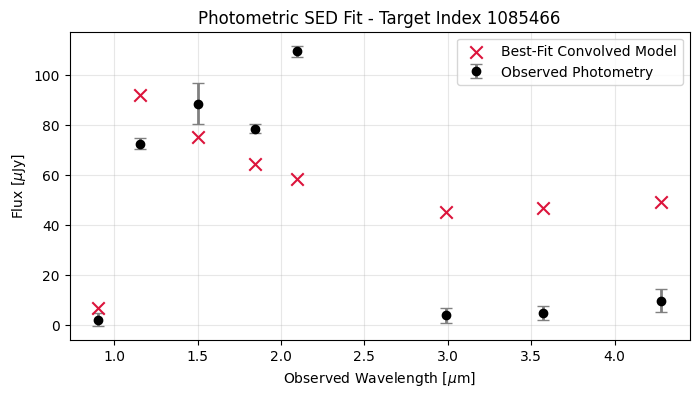

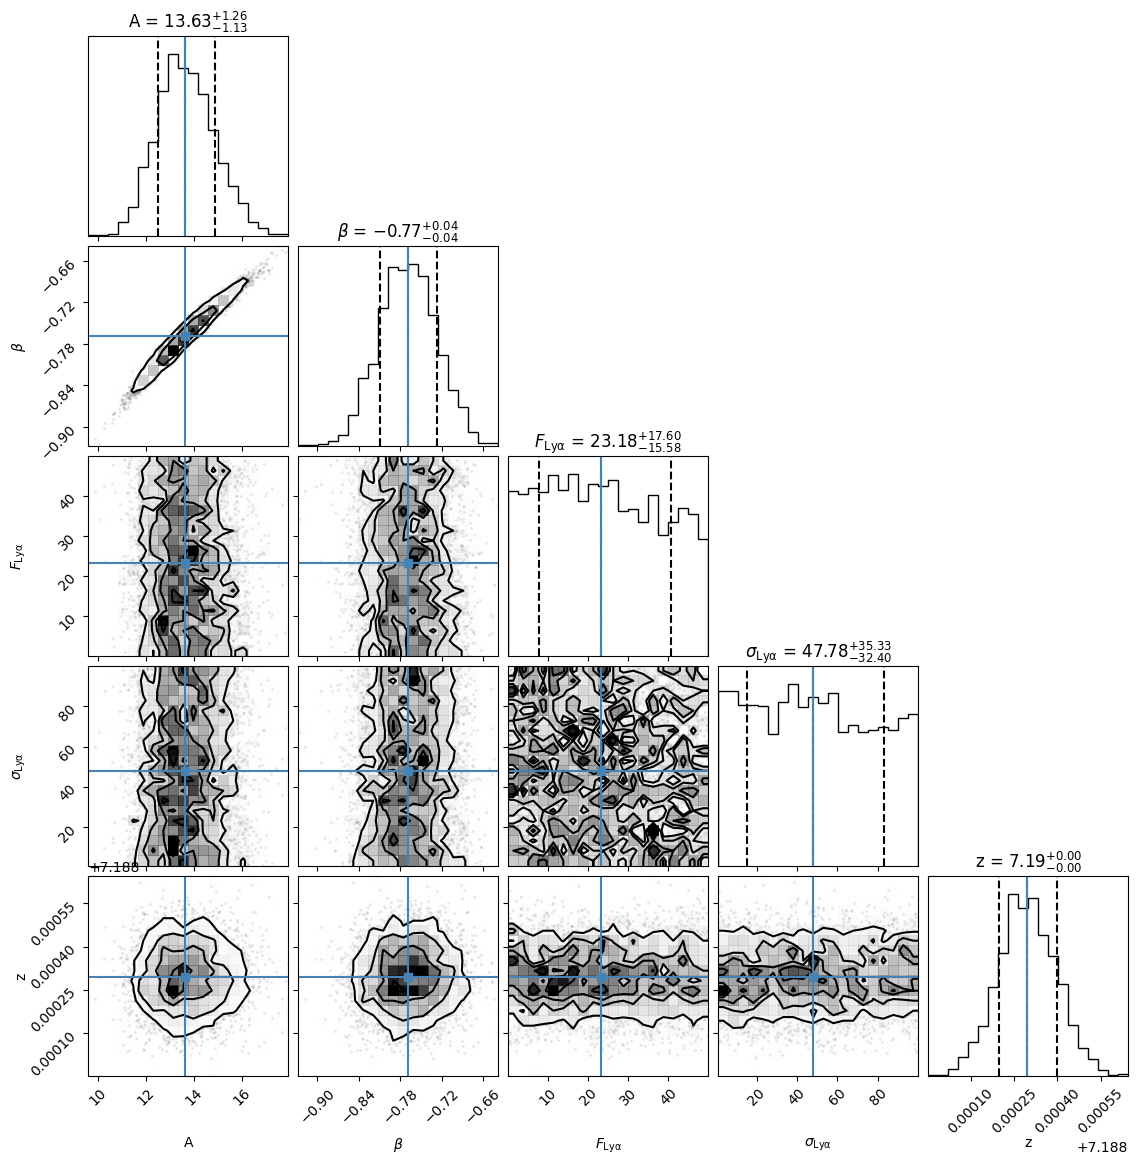

In [229]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import eazy.igm
import eazy.filters

# ==========================================
# 0. CHOOSE A TARGET ROW & EXTRACT FILTERS
# ==========================================
# Let's pick a single row from your dataframe to fit (e.g., index 0)
# row_id = 194756
# target_row = akins_115[akins_115['id'] == row_id][0]

# CHANGE THIS BETWEEN CATALOGS
# active_filters = [filter_file[364], filter_file[365], filter_file[375], filter_file[239]]

# Extract observed data arrays for this target row
# CHANGE THIS BETWEEN CATALOGS
# obs_fluxes = np.array([target_row['flux_814'], target_row['flux_115'], target_row['flux_150'], target_row['flux_277']])
# obs_errors = np.array([target_row['err_814'], target_row['err_115'], target_row['err_150'], target_row['err_277']])


# Extract target-specific EAZY priors for this row
# CHANGE THIS BETWEEN CATALOGS
# z_eazy = target_row['z_gal_med']
# z_err_eazy = (target_row['z_gal_u68'] - target_row['z_gal_l68'])/2

z_eazy = 7.1883
z_err_eazy = 0.0001

# ==========================================
# 1. SETUP MODIFIED PROBABILITY FUNCTIONS
# ==========================================
def log_probability_photometry(theta):
    lp = log_prior_photometry(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_photometry(theta)

def forward_model_photometry(theta, active_filters):
    """
    Generates synthetic photometric fluxes by computing a high-resolution 
    intrinsic model, applying IGM absorption, and integrating through filters.
    
    Parameters:
    -----------
    theta : list or array
        The 5 free parameters: [A, beta, F_Lya, sigma_Lya, z]
    active_filters : list
        List of EAZY filter objects parsed from filters.res
        
    Returns:
    --------
    np.array
        Integrated model fluxes matching the order of active_filters (microJanskies).
    """
    A, beta, F_Lya, sigma_Lya, z = theta
    
    # 1. Setup Intrinsic Model (Everything evaluated in rest-frame Angstroms)
    lambda_Lya_rest = 1215.67
    
    # Map our fixed, fine observed-frame wavelength grid into the rest frame
    wave_rest = fine_model_wave / (1.0 + z)
    
    # Continuum component: Power law normalized at lambda_0 (1700 A)
    flux_cont = A * (wave_rest / lambda_0)**beta
    
    # Line component: Gaussian profile centered at Lyman-alpha
    flux_line = (F_Lya / (np.sqrt(2 * np.pi) * sigma_Lya)) * \
                np.exp(-0.5 * ((wave_rest - lambda_Lya_rest) / sigma_Lya)**2)
    
    f_int = flux_cont + flux_line
    
    # 2. Apply IGM Transmission (Inoue 2014) in the observed frame
    t_igm = igm.full_IGM(z, fine_model_wave)
    f_trans = f_int * t_igm  
    
    # 3. Synthetic Photometry via Filter Profile Integration
    model_fluxes = []
    for filt in active_filters:
        # Interpolate the filter's throughput profile onto our fine internal wavelength grid
        R = np.interp(fine_model_wave, filt.wave, filt.throughput, left=0.0, right=0.0)
        
        # Safety check: if filter footprint falls entirely outside our grid limits
        if np.sum(R) == 0:
            model_fluxes.append(0.0)
            continue
            
        # Photon-weighted integration matching standard detector response
        top = np.trapz(f_trans * R * fine_model_wave, fine_model_wave)
        bottom = np.trapz(R * fine_model_wave, fine_model_wave)
        
        model_fluxes.append(top / bottom)
        
    return np.array(model_fluxes)

def log_likelihood_photometry(theta):
    """
    Computes the Gaussian log-likelihood by comparing the integrated 
    synthetic model fluxes to the observed broadband photometric data points.
    """
    # Evaluate the forward model fluxes for the current parameter step
    model_fluxes = forward_model_photometry(theta, active_filters)
    
    # Standard chi-squared calculation over the available filter bands
    chi2 = np.sum(((obs_fluxes - model_fluxes) / obs_errors)**2)
    
    return -0.5 * chi2

def log_prior_photometry(theta):
    A, beta, F_Lya, sigma_Lya, z = theta
    
    # Apply a hard boundary to isolate the high-z regime entirely
    if not (6.5 < z < 11.0):
        return -np.inf
        
    if not (0.0 < A < 100.0 and -4.0 < beta < 3.0 and 0.0 <= F_Lya < 50.0 and 1.0 < sigma_Lya < 100.0):
        return -np.inf
        
    # Apply your exact Gaussian prior constraint
    log_z_prior = -0.5 * ((z - z_eazy) / z_err_eazy)**2
    return log_z_prior

# ==========================================
# 4. RUN EMCEE SAMPLER (UPDATED FOR 5 PARAMETERS)
# ==========================================
ndim = 5  # Changed to 5: A, beta, F_Lya, sigma_Lya, z
nwalkers = 32
nsteps = 1500

# Guess starting values: [A, beta, F_Lya, sigma_Lya, z]
# We use the median flux for A, and the EAZY peak for z
initial_guess = [np.nanmedian(obs_fluxes), -1.5, 1.0, 15.0, z_eazy]

# Create a small proportional ball around the initial guess
pos = np.zeros((nwalkers, ndim))
for i in range(ndim):
    spread = max(abs(initial_guess[i]) * 0.05, 1e-2)
    pos[:, i] = initial_guess[i] + spread * np.random.randn(nwalkers)

print(f"Running Photometric MCMC chain with {nwalkers} walkers for {nsteps} steps...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_photometry)

# Run MCMC
sampler.run_mcmc(pos, nsteps, progress=True)

# ==========================================
# 5. POST-PROCESSING & PLOTTING (UPDATED)
# ==========================================
# Discard burn-in phase
flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)

# Extract best-fit parameters (median values)
best_fit_theta = np.median(flat_samples, axis=0)
labels = ["A", r"$\beta$", r"$F_{\rm Ly\alpha}$", r"$\sigma_{\rm Ly\alpha}$", "z"]

print("\n--- Fit Results ---")
for i in range(ndim):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{labels[i]} = {p50:.3f} (+{p84-p50:.3f}, -{p50-p16:.3f})")

# Calculate Signal-to-Noise ratio threshold defined in paper
f_lya_mcmc = flat_samples[:, 2]
snr = np.median(f_lya_mcmc) / np.std(f_lya_mcmc)
print(f"LyA Detection S/N = {snr:.2f}")

# --- Plot 1: Discrete Photometric SED Fit ---
# Calculate the pivot wavelengths of your filters to map the X axis (microns)
filter_pivots = np.array([f.pivot / 10000.0 for f in active_filters]) 

plt.figure(figsize=(8, 4))
# Plot observed broadband data points
plt.errorbar(filter_pivots, obs_fluxes, yerr=obs_errors, fmt='o', color='black', 
             ecolor='gray', elinewidth=2, capsize=4, label='Observed Photometry')

# Plot the model equivalent flux points derived through filter integration
best_model_fluxes = forward_model_photometry(best_fit_theta, active_filters)
plt.scatter(filter_pivots, best_model_fluxes, color='crimson', s=80, marker='x', 
            zorder=3, label='Best-Fit Convolved Model')

plt.xlabel(r'Observed Wavelength [$\mu$m]')
plt.ylabel(r'Flux [$ \mu $Jy]')
plt.title(f"Photometric SED Fit - Target Index {row_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot 2: The Posterior Corner Plot ---
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=best_fit_theta,
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

In [213]:
from grizli import utils
from astropy.utils.data import download_file

version = "v4.4" # Updated September 5, 2025.  Include all public spectra even without redshift / line fits

CACHE_DOWNLOADS = True
URL_PREFIX = "https://zenodo.org/records/15472354/files/"

# --- Load MSAEXP emission line catalog ---
table_url = f"{URL_PREFIX}/dja_msaexp_emission_lines_{version}.csv.gz"
spectra = utils.read_catalog(download_file(table_url, cache=CACHE_DOWNLOADS), format='csv')

In [220]:
from astropy.coordinates import SkyCoord
import astropy.units as u

def find_msaexp_file_by_coor(ra_target, dec_target, catalog):
    """
    Finds the closest matching target in the msaexp catalog by RA and Dec,
    and returns its S3 bucket folder root and spec.fits filename.
    """
    # 1. Convert the entire catalog coordinates into SkyCoord structures
    catalog_coords = SkyCoord(ra=catalog['ra']*u.deg, dec=catalog['dec']*u.deg)
    target_coord = SkyCoord(ra=ra_target*u.deg, dec=dec_target*u.deg)
    
    # 2. Match coordinates (finds the absolute closest index)
    idx, d2d, _ = target_coord.match_to_catalog_sky(catalog_coords)
    
    # Extract the matching row
    match_row = catalog[idx]
    
    print(f"Closest match found at separation: {d2d.arcsec[0]:.3f} arcsec")
    if d2d.arcsec[0] > 1.0:
        print("Warning: The closest target is more than 1 arcsecond away. Verify coordinates.")
        
    # 3. Pull the tracking IDs needed to build the filename
    # Typically, msaexp catalogs contain 'root' and 'id' columns
        
    return match_row

find_msaexp_file_by_coor(ra_target=189.08348, dec_target=62.202583, catalog=spectra)

Closest match found at separation: 0.020 arcsec


file,srcid,ra,dec,grating,filter,effexptm,nfiles,dataset,msamet,msaid,msacnf,dithn,slitid,root,npix,ndet,wmin,wmax,wmaxsn,sn10,flux10,err10,sn50,flux50,err50,sn90,flux90,err90,xstart,ystart,xsize,ysize,slit_pa,pa_v3,srcypix,profcen,profsig,ctime,version,exptime,contchi2,dof,fullchi2,line_ariii_7138,line_ariii_7138_err,line_ariii_7753,line_ariii_7753_err,line_bra,line_bra_err,line_brb,line_brb_err,line_brd,line_brd_err,line_brg,line_brg_err,line_hb,line_hb_err,line_hd,line_hd_err,line_hei_1083,line_hei_1083_err,line_hei_3889,line_hei_3889_err,line_hei_5877,line_hei_5877_err,line_hei_7065,line_hei_7065_err,line_hei_8446,line_hei_8446_err,line_heii_4687,line_heii_4687_err,line_hg,line_hg_err,line_lya,line_lya_err,line_mgii,line_mgii_err,line_neiii_3867,line_neiii_3867_err,line_neiii_3968,line_neiii_3968_err,line_nev_3346,line_nev_3346_err,line_nevi_3426,line_nevi_3426_err,line_niii_1750,line_niii_1750_err,line_oi_6302,line_oi_6302_err,line_oii,line_oii_7325,line_oii_7325_err,line_oii_err,line_oiii,line_oiii_1663,line_oiii_1663_err,line_oiii_4363,line_oiii_4363_err,line_oiii_4959,line_oiii_4959_err,line_oiii_5007,line_oiii_5007_err,line_oiii_err,line_pa10,line_pa10_err,line_pa8,line_pa8_err,line_pa9,line_pa9_err,line_paa,line_paa_err,line_pab,line_pab_err,line_pad,line_pad_err,line_pag,line_pag_err,line_pfb,line_pfb_err,line_pfd,line_pfd_err,line_pfe,line_pfe_err,line_pfg,line_pfg_err,line_sii,line_sii_err,line_siii_9068,line_siii_9068_err,line_siii_9531,line_siii_9531_err,spl_0,spl_0_err,spl_1,spl_10,spl_10_err,spl_11,spl_11_err,spl_12,spl_12_err,spl_13,spl_13_err,spl_14,spl_14_err,spl_15,spl_15_err,spl_16,spl_16_err,spl_17,spl_17_err,spl_18,spl_18_err,spl_19,spl_19_err,spl_1_err,spl_2,spl_20,spl_20_err,spl_21,spl_21_err,spl_22,spl_22_err,spl_2_err,spl_3,spl_3_err,spl_4,spl_4_err,spl_5,spl_5_err,spl_6,spl_6_err,spl_7,spl_7_err,spl_8,spl_8_err,spl_9,spl_9_err,zline,line_civ_1549,line_civ_1549_err,line_h10,line_h10_err,line_h11,line_h11_err,line_h12,line_h12_err,line_h7,line_h7_err,line_h8,line_h8_err,line_h9,line_h9_err,line_ha,line_ha_err,line_hei_6680,line_hei_6680_err,line_heii_1640,line_heii_1640_err,line_nii_6549,line_nii_6549_err,line_nii_6584,line_nii_6584_err,line_oii_7323,line_oii_7323_err,line_oii_7332,line_oii_7332_err,line_sii_6717,line_sii_6717_err,line_sii_6731,line_sii_6731_err,line_siii_6314,line_siii_6314_err,escale0,escale1,line_ciii_1906,line_ciii_1906_err,line_niv_1487,line_niv_1487_err,line_pah_3p29,line_pah_3p29_err,line_pah_3p40,line_pah_3p40_err,eqw_ariii_7138,eqw_ariii_7753,eqw_bra,eqw_brb,eqw_brd,eqw_brg,eqw_ciii_1906,eqw_civ_1549,eqw_ha_nii,eqw_hb,eqw_hd,eqw_hei_1083,eqw_hei_3889,eqw_hei_5877,eqw_hei_7065,eqw_hei_8446,eqw_heii_1640,eqw_heii_4687,eqw_hg,eqw_lya,eqw_mgii,eqw_neiii_3867,eqw_neiii_3968,eqw_nev_3346,eqw_nevi_3426,eqw_niii_1750,eqw_niv_1487,eqw_oi_6302,eqw_oii,eqw_oii_7325,eqw_oiii,eqw_oiii_1663,eqw_oiii_4363,eqw_oiii_4959,eqw_oiii_5007,eqw_pa10,eqw_pa8,eqw_pa9,eqw_paa,eqw_pab,eqw_pad,eqw_pag,eqw_pfb,eqw_pfd,eqw_pfe,eqw_pfg,eqw_sii,eqw_siii_9068,eqw_siii_9531,line_ha_nii,line_ha_nii_err,eqw_h10,eqw_h11,eqw_h12,eqw_h7,eqw_h8,eqw_h9,eqw_ha,eqw_hei_6680,eqw_nii_6549,eqw_nii_6584,eqw_oii_7323,eqw_oii_7332,eqw_sii_6717,eqw_sii_6731,eqw_siii_6314,sn_line,ztime,line_ci_9850,line_ci_9850_err,line_feii_11128,line_feii_11128_err,line_pii_11886,line_pii_11886_err,line_feii_12570,line_feii_12570_err,eqw_ci_9850,eqw_feii_11128,eqw_pii_11886,eqw_feii_12570,line_feii_16440,line_feii_16440_err,line_feii_16877,line_feii_16877_err,line_brf,line_brf_err,line_feii_17418,line_feii_17418_err,line_bre,line_bre_err,line_feii_18362,line_feii_18362_err,eqw_feii_16440,eqw_feii_16877,eqw_brf,eqw_feii_17418,eqw_bre,eqw_feii_18362,valid,objid,z_best,ztype,z_prism,z_grating,phot_correction,phot_flux_radius,phot_dr,file_phot,id_phot,phot_mag_auto,phot_f090w_tot_1,phot_f090w_etot_1,phot_f115w_tot_1,phot_f115w_etot_1,phot_f150w_tot_1,phot_f150w_etot_1,phot_f200w_tot_1,phot_f200w_etot_1,phot_f277w_tot_1,phot_f277w_etot_1,phot_f

In [223]:
with fits.open('https://s3.amazonaws.com/msaexp-nirspec/extractions/gdn-fujimoto-v4/gdn-fujimoto-v4_g140m-f070lp_4762_33609.spec.fits') as hdul:
    spec_data = Table(hdul['SPEC1D'].data)

spec_data

wave,flux,err,sky,path_corr,npix,flux_sum,profile_sum,var_sum
float64,float64,float64,float64,float64,float64,float64,float64,float64
0.55,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5506000000000001,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5512000000000001,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5518000000000002,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5524000000000002,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5530000000000003,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5536000000000003,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5542000000000004,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5548000000000004,nan,nan,nan,nan,0.0,0.0,0.0,0.0


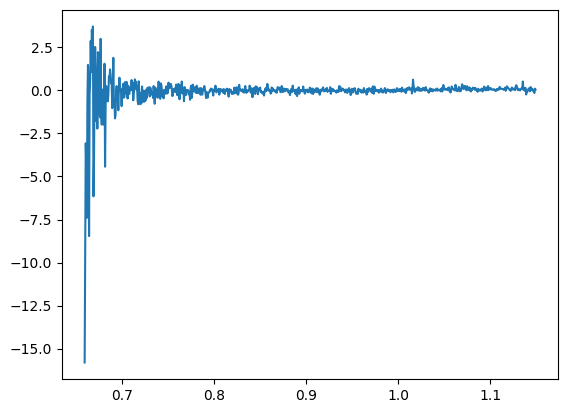

In [226]:
plt.figure()
plt.plot(spec_data['wave'][0:1000], spec_data['flux'][0:1000])